In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# load the arrays
import numpy as np

X = np.load("/content/drive/MyDrive/.npy_files/NEW_ROI_X.npy")
Y = np.load("/content/drive/MyDrive/.npy_files/NEW_ROI_Y.npy")

print("X shape:", X.shape)
print("Y shape:", Y.shape)

print("X dtype:", X.dtype)
print("Y dtype:", Y.dtype)

X shape: (3242, 128, 128, 1)
Y shape: (3242, 128, 128, 1)
X dtype: float32
Y dtype: uint8


In [ ]:
print(X.shape)
print(Y.shape)
print(X.dtype)
print(Y.dtype)
print(np.unique(Y))

(3242, 128, 128, 1)
(3242, 128, 128, 1)
float32
uint8
[0 1]


In [ ]:
print("X min :", X.min())
print("X max :", X.max())

print("Unique mask values:")
print(np.unique(Y))

X min : 0.003921569
X max : 1.0000001
Unique mask values:
[0 1]


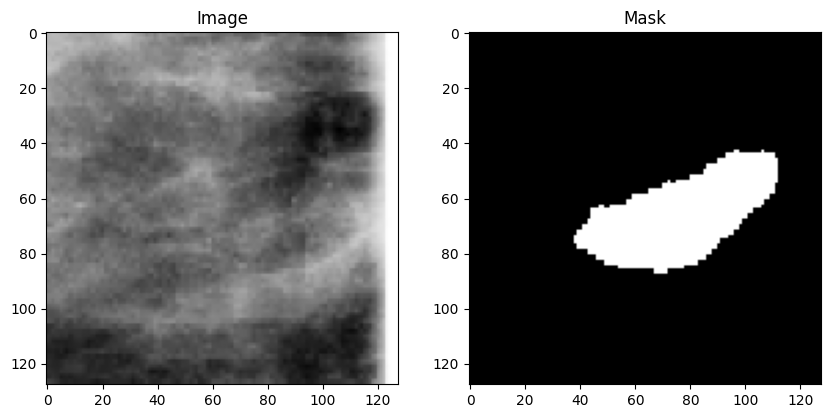

In [ ]:
# display one image
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(X[0].squeeze(), cmap="gray")
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(Y[0].squeeze(), cmap="gray")
plt.title("Mask")

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# 70% Train, 30% Temp
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X,
    Y,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

# 15% Validation, 15% Test
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp,
    Y_temp,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print("Training Set")
print(X_train.shape, Y_train.shape)

print("\nValidation Set")
print(X_val.shape, Y_val.shape)

print("\nTesting Set")
print(X_test.shape, Y_test.shape)

Training Set
(2269, 128, 128, 1) (2269, 128, 128, 1)

Validation Set
(486, 128, 128, 1) (486, 128, 128, 1)

Testing Set
(487, 128, 128, 1) (487, 128, 128, 1)


In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from tqdm import tqdm

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

Using Device: cuda


In [ ]:
# load dataset
X = np.load("/content/drive/MyDrive/.npy_files/NEW_ROI_X.npy")
Y = np.load("/content/drive/MyDrive/.npy_files/NEW_ROI_Y.npy")


print("Images :", X.shape)
print("Masks  :", Y.shape)

Images : (3242, 128, 128, 1)
Masks  : (3242, 128, 128, 1)


In [ ]:
# split dataset
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X,
    Y,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp,
    Y_temp,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print("Train :", X_train.shape)
print("Val   :", X_val.shape)
print("Test  :", X_test.shape)

NameError: name 'train_test_split' is not defined

In [ ]:
# py-torch dataset class
class MammogramDataset(Dataset):

    def __init__(self, images, masks):
        self.images = images
        self.masks = masks

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image = torch.tensor(
            self.images[idx],
            dtype=torch.float32
        ).permute(2,0,1)

        mask = torch.tensor(
            self.masks[idx],
            dtype=torch.float32
        ).permute(2,0,1)

        return image, mask

In [ ]:
# Data loaders
BATCH_SIZE = 8

train_dataset = MammogramDataset(X_train, Y_train)
val_dataset = MammogramDataset(X_val, Y_val)
test_dataset = MammogramDataset(X_test, Y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))

Train batches: 284


In [ ]:
images, masks = next(iter(train_loader))

print("Images Shape :", images.shape)
print("Masks Shape  :", masks.shape)

print("Images dtype :", images.dtype)
print("Masks dtype  :", masks.dtype)

print("Mask values  :", torch.unique(masks))

Images Shape : torch.Size([8, 1, 128, 128])
Masks Shape  : torch.Size([8, 1, 128, 128])
Images dtype : torch.float32
Masks dtype  : torch.float32
Mask values  : tensor([0., 1.])


In [ ]:
# verify dataloader
images, masks = next(iter(train_loader))

print(images.shape)
print(masks.shape)

torch.Size([8, 1, 128, 128])
torch.Size([8, 1, 128, 128])


In [ ]:
!pip install -q segmentation-models-pytorch
!pip install -q torchmetrics

In [ ]:
import segmentation_models_pytorch as smp

import torch
import torch.nn as nn
import torch.optim as optim

from torchmetrics.classification import (
    BinaryAccuracy,
    BinaryPrecision,
    BinaryRecall,
    BinaryF1Score
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [ ]:
model = smp.UnetPlusPlus(

    encoder_name="resnet34",
    encoder_weights="imagenet",

    in_channels=1,
    classes=1,

    activation=None

)

model = model.to(device)

print(model)

UnetPlusPlus(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tru

In [ ]:
images, masks = next(iter(train_loader))

images = images.to(device)

outputs = model(images)

print("Output Shape :", outputs.shape)
print("Output dtype :", outputs.dtype)

Output Shape : torch.Size([8, 1, 128, 128])
Output dtype : torch.float32


In [ ]:
bce_loss = nn.BCEWithLogitsLoss()

dice_loss = smp.losses.DiceLoss(
    mode="binary",
    from_logits=True
)

def total_loss(pred, target):

    bce = bce_loss(pred, target)
    dice = dice_loss(pred, target)

    return bce + dice

In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-5,
    weight_decay=1e-4
)

In [ ]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="max",

    factor=0.5,

    patience=2

)

In [ ]:
accuracy = BinaryAccuracy().to(device)

precision = BinaryPrecision().to(device)

recall = BinaryRecall().to(device)

f1 = BinaryF1Score().to(device)

In [ ]:
def dice_score(pred, target, smooth=1e-6):

    pred = torch.sigmoid(pred)

    pred = (pred > 0.5).float()

    intersection = (pred * target).sum()

    union = pred.sum() + target.sum()

    return (2 * intersection + smooth) / (union + smooth)

In [ ]:
def iou_score(pred, target, smooth=1e-6):

    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection

    return (intersection + smooth) / (union + smooth)

In [ ]:
# Training Function
def train_one_epoch(model, loader, optimizer):

    model.train()

    running_loss = 0
    running_dice = 0
    running_iou = 0

    progress = tqdm(loader, desc="Training", leave=False)

    for images, masks in progress:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = total_loss(outputs, masks)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()
        running_dice += dice_score(outputs, masks).item()
        running_iou += iou_score(outputs, masks).item()

        progress.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(loader)
    epoch_dice = running_dice / len(loader)
    epoch_iou = running_iou / len(loader)

    return epoch_loss, epoch_dice, epoch_iou

In [ ]:
# Validation function
def validate(model, loader):

    model.eval()

    running_loss = 0
    running_dice = 0
    running_iou = 0

    acc = 0
    prec = 0
    rec = 0
    f1score = 0

    with torch.no_grad():

        progress = tqdm(loader, desc="Validation", leave=False)

        for images, masks in progress:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = total_loss(outputs, masks)

            running_loss += loss.item()

            running_dice += dice_score(outputs, masks).item()
            running_iou += iou_score(outputs, masks).item()

            preds = (torch.sigmoid(outputs) > 0.5).float()

            acc += accuracy(preds, masks).item()
            prec += precision(preds, masks).item()
            rec += recall(preds, masks).item()
            f1score += f1(preds, masks).item()

    epoch_loss = running_loss / len(loader)
    epoch_dice = running_dice / len(loader)
    epoch_iou = running_iou / len(loader)

    epoch_acc = acc / len(loader)
    epoch_prec = prec / len(loader)
    epoch_rec = rec / len(loader)
    epoch_f1 = (
        2 * epoch_prec * epoch_rec
    ) / (
        epoch_prec + epoch_rec + 1e-8
    )

    return (
        epoch_loss,
        epoch_dice,
        epoch_iou,
        epoch_acc,
        epoch_prec,
        epoch_rec,
        epoch_f1
    )

In [ ]:
best_dice = 0

early_stop_counter = 0
early_stop_patience = 5

In [ ]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_dice": [],
    "val_dice": [],
    "val_iou": [],
}

In [ ]:
EPOCHS = 50

best_dice = float("-inf")

history = {
    "train_loss": [],
    "val_loss": [],
    "train_dice": [],
    "val_dice": [],
    "train_iou": [],
    "val_iou": [],
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": []
}

for epoch in range(EPOCHS):

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    train_loss, train_dice, train_iou = train_one_epoch(
        model,
        train_loader,
        optimizer
    )

    (
        val_loss,
        val_dice,
        val_iou,
        val_acc,
        val_prec,
        val_rec,
        val_f1

    ) = validate(model, val_loader)

    scheduler.step(val_dice)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_dice"].append(train_dice)
    history["val_dice"].append(val_dice)

    history["train_iou"].append(train_iou)
    history["val_iou"].append(val_iou)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")

    print(f"Train Dice : {train_dice:.4f}")
    print(f"Val Dice   : {val_dice:.4f}")

    print(f"Val IoU    : {val_iou:.4f}")

    print(f"Accuracy   : {val_acc:.4f}")
    print(f"Precision  : {val_prec:.4f}")
    print(f"Recall     : {val_rec:.4f}")
    print(f"F1 Score   : {val_f1:.4f}")

    if val_dice > best_dice:

        best_dice = val_dice
        early_stop_counter = 0

        checkpoint = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_dice": best_dice,
            "val_loss": val_loss,
            "scheduler_state_dict": scheduler.state_dict(),
        }

        torch.save(
          checkpoint,
          "/content/drive/MyDrive/ELC/best_unetplusplus_checkpoint.pth"
        )

        print("Best model saved!")

    else:

        early_stop_counter += 1

        print(f"EarlyStopping Counter: {early_stop_counter}/{early_stop_patience}")

    if early_stop_counter >= early_stop_patience:

        print("\n🛑 Early stopping triggered!")
        break


Epoch [1/50]


Train Loss : 0.8786
Val Loss   : 0.6464
Train Dice : 0.6772
Val Dice   : 0.7873
Val IoU    : 0.6516
Accuracy   : 0.9618
Precision  : 0.6947
Recall     : 0.9138
F1 Score   : 0.7894
Best model saved!

Epoch [2/50]


Train Loss : 0.5579
Val Loss   : 0.5008
Train Dice : 0.7976
Val Dice   : 0.8013
Val IoU    : 0.6726
Accuracy   : 0.9678
Precision  : 0.7827
Recall     : 0.8296
F1 Score   : 0.8055
Best model saved!

Epoch [3/50]


Train Loss : 0.4338
Val Loss   : 0.4239
Train Dice : 0.8190
Val Dice   : 0.8081
Val IoU    : 0.6816
Accuracy   : 0.9696
Precision  : 0.8065
Recall     : 0.8167
F1 Score   : 0.8116
Best model saved!

Epoch [4/50]


Train Loss : 0.3588
Val Loss   : 0.4185
Train Dice : 0.8328
Val Dice   : 0.7734
Val IoU    : 0.6341
Accuracy   : 0.9632
Precision  : 0.7585
Recall     : 0.8004
F1 Score   : 0.7789
EarlyStopping Counter: 1/5

Epoch [5/50]


...

Train Loss : 0.2293
Val Loss   : 0.3158
Train Dice : 0.8752
Val Dice   : 0.8183
Val IoU    : 0.6953
Accuracy   : 0.9706
Precision  : 0.7993
Recall     : 0.8456
F1 Score   : 0.8218
EarlyStopping Counter: 1/5

Epoch [8/50]


Train Loss : 0.2080
Val Loss   : 0.3128
Train Dice : 0.8837
Val Dice   : 0.8134
Val IoU    : 0.6876
Accuracy   : 0.9714
Precision  : 0.8311
Recall     : 0.8024
F1 Score   : 0.8165
EarlyStopping Counter: 2/5

Epoch [9/50]


Train Loss : 0.1895
Val Loss   : 0.3121
Train Dice : 0.8914
Val Dice   : 0.8134
Val IoU    : 0.6879
Accuracy   : 0.9711
Precision  : 0.8208
Recall     : 0.8121
F1 Score   : 0.8164
EarlyStopping Counter: 3/5

Epoch [10/50]


Train Loss : 0.1612
Val Loss   : 0.3057
Train Dice : 0.9080
Val Dice   : 0.8176
Val IoU    : 0.6937
Accuracy   : 0.9719
Precision  : 0.8324
Recall     : 0.8085
F1 Score   : 0.8203
EarlyStopping Counter: 4/5

Epoch [11/50]


Train Loss : 0.1435
Val Loss   : 0.3033
Train Dice : 0.9184
Val Dice   : 0.8192
Val IoU    : 0.6962
Accuracy   : 0.9718
Precision  : 0.8230
Recall     : 0.8209
F1 Score   : 0.8220
EarlyStopping Counter: 5/5

🛑 Early stopping triggered!


In [ ]:
import torch
import os

save_dir = "/content/drive/MyDrive/ELC"
os.makedirs(save_dir, exist_ok=True)

checkpoint = {
    "epoch": 49,   # completed 50 epochs (0-indexed)
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "best_dice": best_dice,
}

torch.save(
    checkpoint,
    os.path.join(save_dir, "best_unetplusplus_checkpoint.pth")
)

print("✅ Checkpoint saved successfully!")

✅ Checkpoint saved successfully!


In [ ]:
# if val_dice > best_dice + min_delta:

#     best_dice = val_dice
#     early_stop_counter = 0

#     torch.save({
#         "epoch": epoch,
#         "model_state_dict": model.state_dict(),
#         "optimizer_state_dict": optimizer.state_dict(),
#         "best_dice": best_dice
#     }, "/content/drive/MyDrive/ELC")

NameError: name 'min_delta' is not defined

In [ ]:
import pickle

with open(os.path.join(save_dir, "history.pkl"), "wb") as f:
    pickle.dump(history, f)

print("✅ History saved successfully!")

✅ History saved successfully!


In [ ]:
import os

save_dir = "/content/drive/MyDrive/ELC"

if os.path.exists(save_dir):
    print("Files in ELC folder:")
    print(os.listdir(save_dir))
else:
    print("ELC folder does not exist.")

Files in ELC folder:
['X.npy', 'Y.npy', 'best_unetplusplus_checkpoint.pth', 'history.pkl', 'Final_Model_Results.csv', 'UNET++.ipynb']


In [ ]:
import pickle

with open("/content/drive/MyDrive/ELC/history.pkl", "wb") as f:
    pickle.dump(history, f)

print("History saved!")

History saved!


In [ ]:
checkpoint = torch.load(
    "/content/drive/MyDrive/ELC/best_unetplusplus_checkpoint.pth",
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])

optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

best_dice = checkpoint["best_dice"]

start_epoch = checkpoint["epoch"] + 1

print("Resumed from epoch:", start_epoch)

Resumed from epoch: 50


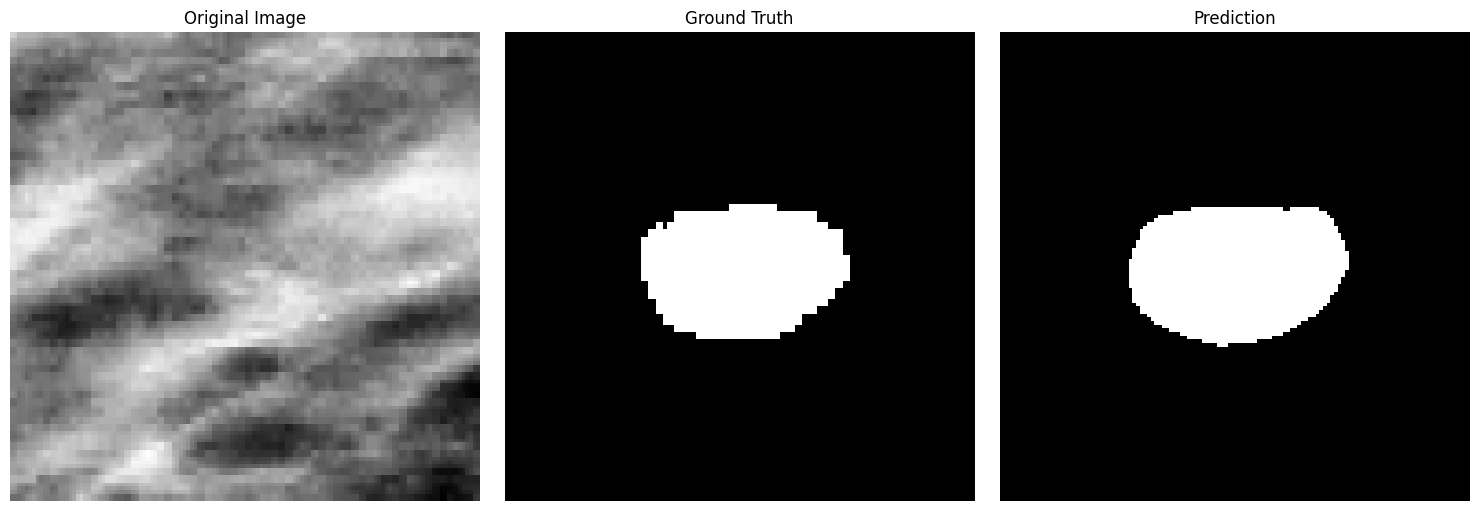

In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np
import torch

# Put model in evaluation mode
model.eval()

# Select a random image
idx = random.randint(0, len(X)-1)

image = X[idx]      # (256,256,1)
mask = Y[idx]       # (256,256,1)

# Convert image to tensor
image_tensor = torch.from_numpy(image).permute(2,0,1).unsqueeze(0).float().to(device)

with torch.no_grad():
    pred = model(image_tensor)
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

pred_mask = pred.squeeze().cpu().numpy()

# Plot
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image.squeeze(), cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask.squeeze(), cmap='gray')
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred_mask, cmap='gray')
plt.title("Prediction")
plt.axis("off")

plt.tight_layout()
plt.show()

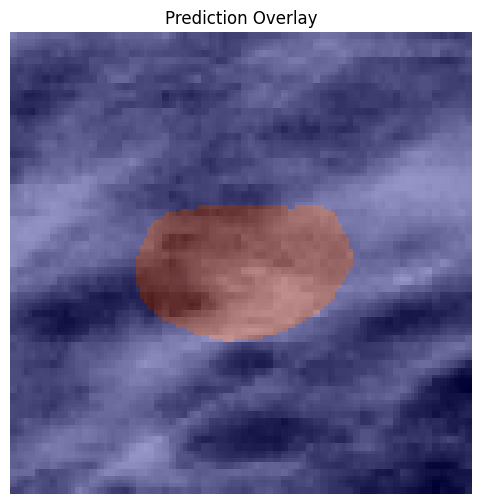

In [ ]:
plt.figure(figsize=(6,6))

plt.imshow(image.squeeze(), cmap='gray')
plt.imshow(pred_mask, cmap='jet', alpha=0.4)

plt.title("Prediction Overlay")
plt.axis("off")
plt.show()

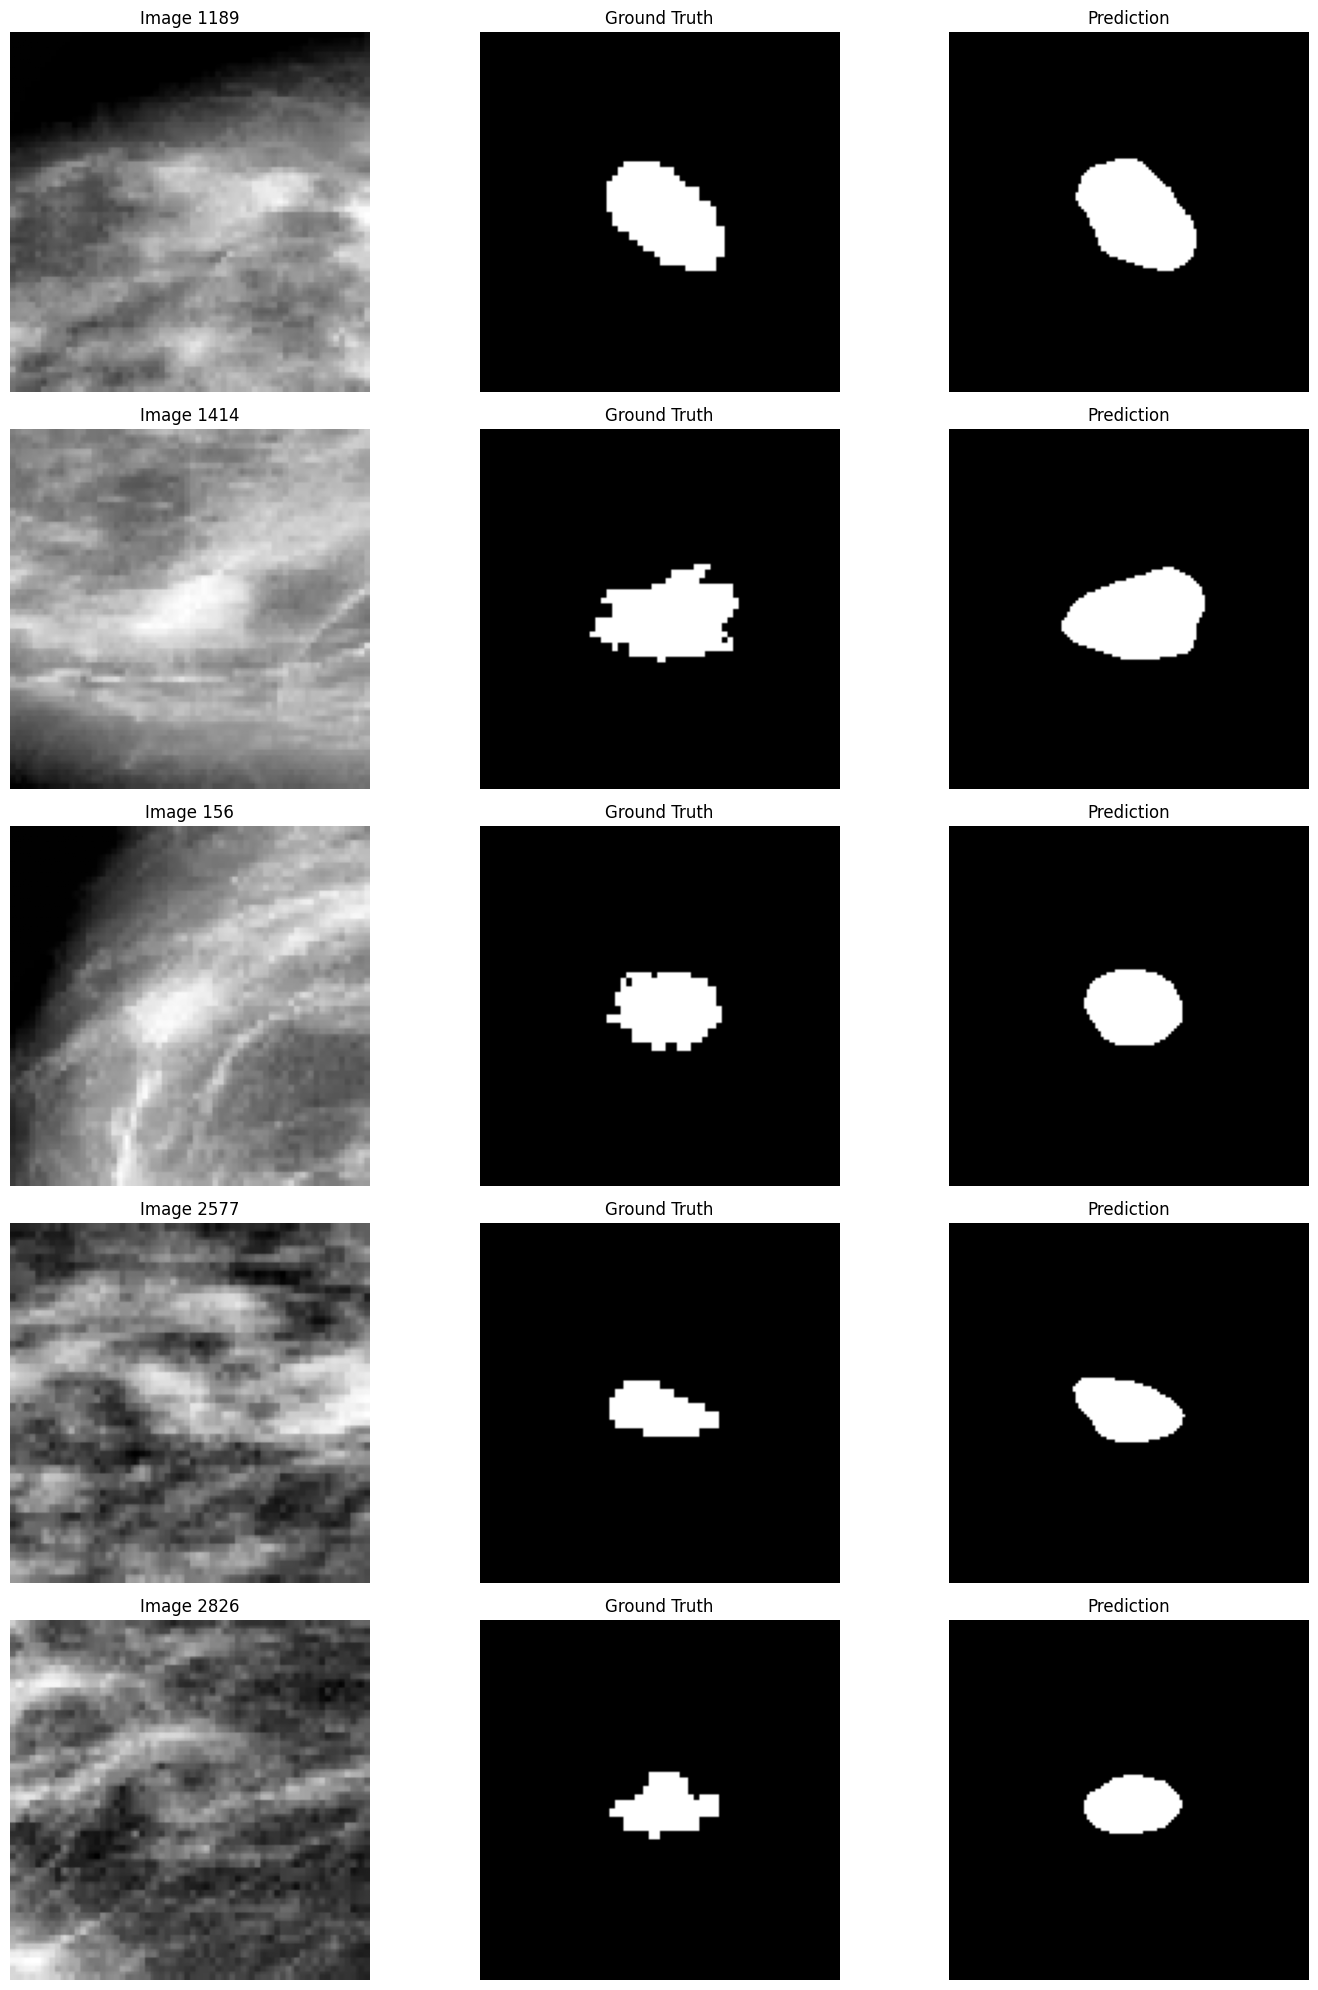

In [ ]:
import random
import matplotlib.pyplot as plt
import torch
import numpy as np

# Set model to evaluation mode
model.eval()

# Select 5 random indices
indices = random.sample(range(len(X)), 5)

plt.figure(figsize=(15, 20))

for i, idx in enumerate(indices):

    # Get image and mask
    image = X[idx]          # (256,256,1)
    mask = Y[idx]           # (256,256,1)

    # Convert image to tensor
    image_tensor = (
        torch.from_numpy(image)
        .permute(2, 0, 1)
        .unsqueeze(0)
        .float()
        .to(device)
    )

    # Prediction
    with torch.no_grad():
        pred = model(image_tensor)
        pred = torch.sigmoid(pred)
        pred = (pred > 0.5).float()

    pred_mask = pred.squeeze().cpu().numpy()

    # Original Image
    plt.subplot(5, 3, 3*i + 1)
    plt.imshow(image.squeeze(), cmap='gray')
    plt.title(f"Image {idx}")
    plt.axis("off")

    # Ground Truth
    plt.subplot(5, 3, 3*i + 2)
    plt.imshow(mask.squeeze(), cmap='gray')
    plt.title("Ground Truth")
    plt.axis("off")

    # Prediction
    plt.subplot(5, 3, 3*i + 3)
    plt.imshow(pred_mask, cmap='gray')
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

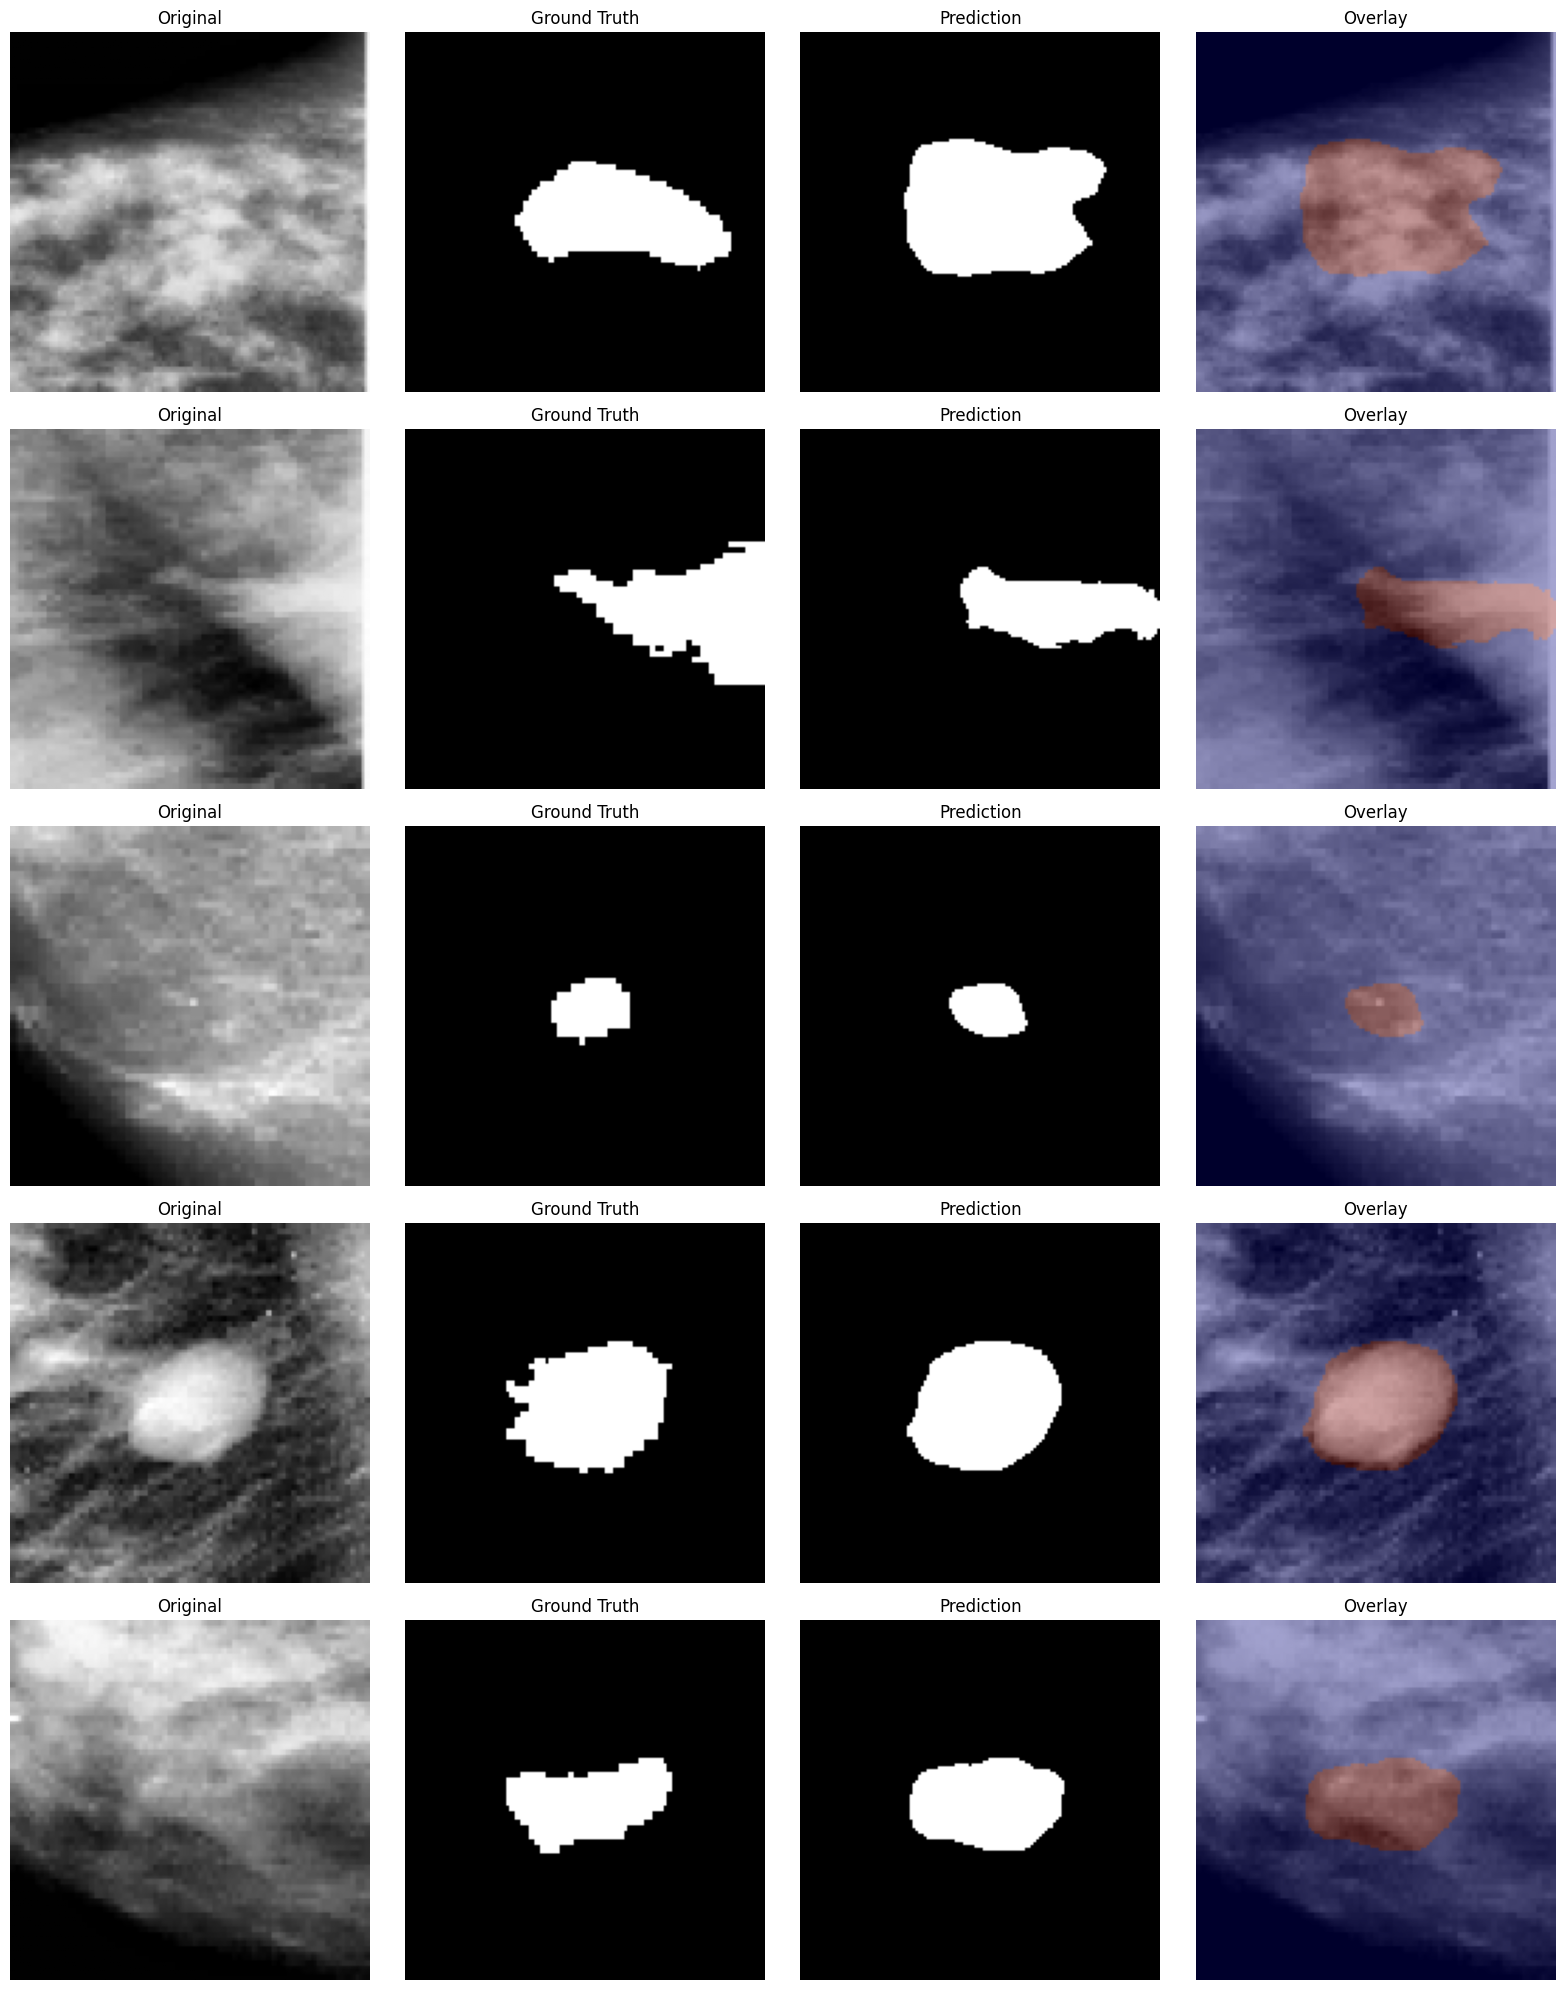

In [ ]:
import random
import torch
import matplotlib.pyplot as plt

model.eval()

indices = random.sample(range(len(X_test)), 5)

plt.figure(figsize=(16,20))

for i, idx in enumerate(indices):

    image = X_test[idx]
    mask = Y_test[idx]

    image_tensor = (
        torch.from_numpy(image)
        .permute(2,0,1)
        .unsqueeze(0)
        .float()
        .to(device)
    )

    with torch.no_grad():
        pred = model(image_tensor)
        pred = torch.sigmoid(pred)
        pred = (pred > 0.5).float()

    pred_mask = pred.squeeze().cpu().numpy()

    # Original Image
    plt.subplot(5,4,4*i+1)
    plt.imshow(image.squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Ground Truth
    plt.subplot(5,4,4*i+2)
    plt.imshow(mask.squeeze(), cmap='gray')
    plt.title("Ground Truth")
    plt.axis("off")

    # Prediction
    plt.subplot(5,4,4*i+3)
    plt.imshow(pred_mask, cmap='gray')
    plt.title("Prediction")
    plt.axis("off")

    # Overlay
    plt.subplot(5,4,4*i+4)
    plt.imshow(image.squeeze(), cmap='gray')
    plt.imshow(pred_mask, cmap='jet', alpha=0.35)
    plt.title("Overlay")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, jaccard_score
import numpy as np
import torch

model.eval()

dice_scores = []
iou_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

with torch.no_grad():

    for i in range(len(X_test)):

        image = X_test[i]
        mask = Y_test[i]

        image_tensor = (
            torch.from_numpy(image)
            .permute(2,0,1)
            .unsqueeze(0)
            .float()
            .to(device)
        )

        pred = model(image_tensor)
        pred = torch.sigmoid(pred)
        pred = (pred > 0.5).float()

        pred_mask = pred.squeeze().cpu().numpy().astype(np.uint8)
        gt_mask = mask.squeeze().astype(np.uint8)

        # Flatten
        y_true = gt_mask.flatten()
        y_pred = pred_mask.flatten()

        # Dice
        intersection = np.sum(y_true * y_pred)

        dice = (2 * intersection + 1e-6) / (
            np.sum(y_true) + np.sum(y_pred) + 1e-6
        )

        dice_scores.append(dice)

        # IoU
        iou_scores.append(
            jaccard_score(
                y_true,
                y_pred,
                zero_division=0
            )
        )

        # Precision
        precision_val = precision_score(
        y_true,
        y_pred,
        zero_division=0
        )

        # Recall
        recall_val = recall_score(
        y_true,
        y_pred,
        zero_division=0
        )

        # Save values
        precision_scores.append(precision_val)
        recall_scores.append(recall_val)

        # F1 (Harmonic Mean)
        f1 = (2 * precision_val * recall_val) / (
        precision_val + recall_val + 1e-8
        )

        f1_scores.append(f1)

In [ ]:
print("="*45)
print("TEST SET RESULTS")
print("="*45)

print(f"Mean Dice Score : {np.mean(dice_scores):.4f}")
print(f"Mean IoU        : {np.mean(iou_scores):.4f}")
print(f"Mean Precision  : {np.mean(precision_scores):.4f}")
print(f"Mean Recall     : {np.mean(recall_scores):.4f}")
print(f"Mean F1 Score   : {np.mean(f1_scores):.4f}")

TEST SET RESULTS
Mean Dice Score : 0.8065
Mean IoU        : 0.6928
Mean Precision  : 0.8294
Mean Recall     : 0.8159
Mean F1 Score   : 0.8065


In [ ]:
# save the results
results = {
    "Dice": np.mean(dice_scores),
    "IoU": np.mean(iou_scores),
    "Precision": np.mean(precision_scores),
    "Recall": np.mean(recall_scores),
    "F1": np.mean(f1_scores)
}

print(results)

{'Dice': np.float64(0.8064623327161198), 'IoU': np.float64(0.6927567396620845), 'Precision': np.float64(0.8293542890821373), 'Recall': np.float64(0.8159181554949535), 'F1': np.float64(0.8064623276475869)}


In [ ]:
from sklearn.metrics import precision_score, recall_score, jaccard_score
import numpy as np
import torch

def evaluate_dataset(model, X_data, Y_data, device):

    model.eval()

    dice_scores = []
    iou_scores = []
    precision_scores = []
    recall_scores = []

    with torch.no_grad():

        for i in range(len(X_data)):

            image = X_data[i]
            mask = Y_data[i]

            image_tensor = (
                torch.from_numpy(image)
                .permute(2,0,1)
                .unsqueeze(0)
                .float()
                .to(device)
            )

            pred = model(image_tensor)
            pred = torch.sigmoid(pred)
            pred = (pred > 0.5).float()

            pred_mask = pred.squeeze().cpu().numpy().astype(np.uint8)
            gt_mask = mask.squeeze().astype(np.uint8)

            y_true = gt_mask.flatten()
            y_pred = pred_mask.flatten()

            # Dice
            intersection = np.sum(y_true * y_pred)

            dice = (2 * intersection + 1e-6) / (
                np.sum(y_true) + np.sum(y_pred) + 1e-6
            )

            dice_scores.append(dice)

            # IoU
            iou_scores.append(
                jaccard_score(y_true, y_pred, zero_division=0)
            )

            # Precision
            precision = precision_score(
                y_true,
                y_pred,
                zero_division=0
            )
            precision_scores.append(precision)

            # Recall
            recall = recall_score(
                y_true,
                y_pred,
                zero_division=0
            )
            recall_scores.append(recall)

    # Dataset averages
    mean_precision = np.mean(precision_scores)
    mean_recall = np.mean(recall_scores)

    # Harmonic Mean
    mean_f1 = (
        2 * mean_precision * mean_recall
    ) / (
        mean_precision + mean_recall + 1e-8
    )

    return {
        "Dice": np.mean(dice_scores),
        "IoU": np.mean(iou_scores),
        "Precision": mean_precision,
        "Recall": mean_recall,
        "F1": mean_f1
    }

In [ ]:
train_results = evaluate_dataset(model, X_train, Y_train, device)

val_results = evaluate_dataset(model, X_val, Y_val, device)

test_results = evaluate_dataset(model, X_test, Y_test, device)

In [ ]:
import pandas as pd

results_df = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "Dice": [
        train_results["Dice"],
        val_results["Dice"],
        test_results["Dice"]
    ],
    "IoU": [
        train_results["IoU"],
        val_results["IoU"],
        test_results["IoU"]
    ],
    "Precision": [
        train_results["Precision"],
        val_results["Precision"],
        test_results["Precision"]
    ],
    "Recall": [
        train_results["Recall"],
        val_results["Recall"],
        test_results["Recall"]
    ],
    "F1 Score": [
        train_results["F1"],
        val_results["F1"],
        test_results["F1"]
    ]
})

results_df = results_df.round(4)

print(results_df)

      Dataset    Dice     IoU  Precision  Recall  F1 Score
0       Train  0.8992  0.8278     0.9064  0.9030    0.9047
1  Validation  0.7997  0.6857     0.8173  0.8178    0.8176
2        Test  0.8065  0.6928     0.8294  0.8159    0.8226


In [ ]:
results_df.to_csv(
    "/content/drive/MyDrive/ELC/Final_Model_Results.csv",
    index=False
)

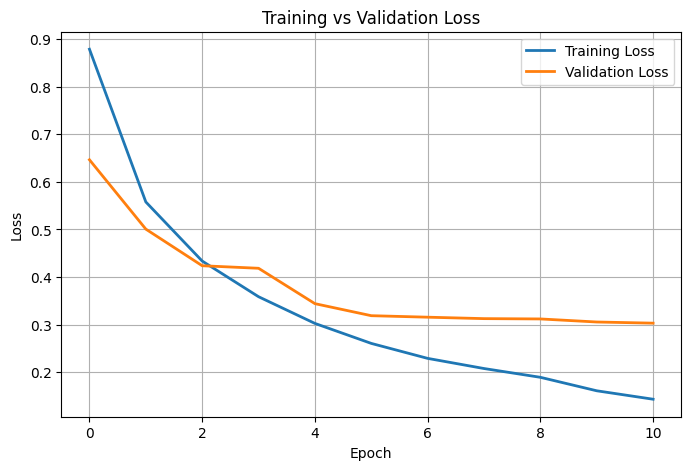

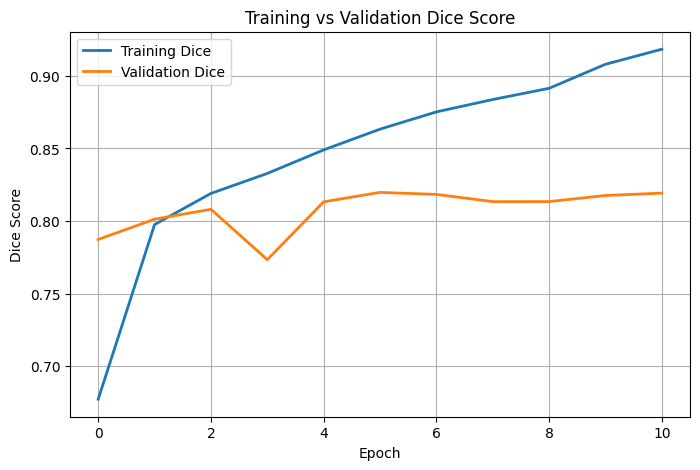

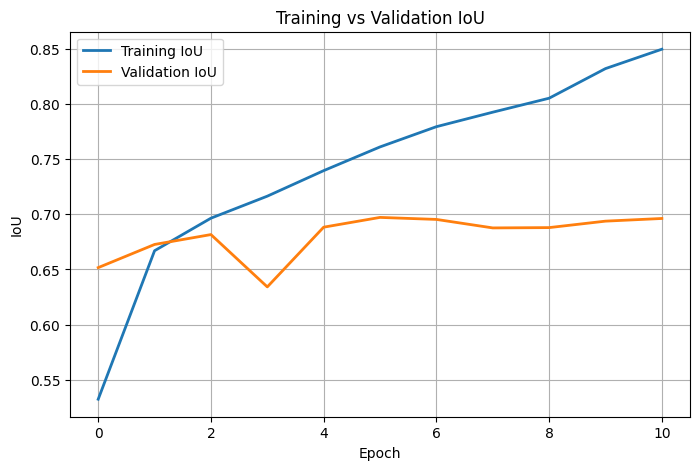

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history["train_loss"], label="Training Loss", linewidth=2)
plt.plot(history["val_loss"], label="Validation Loss", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

plt.figure(figsize=(8,5))

plt.plot(history["train_dice"], label="Training Dice", linewidth=2)
plt.plot(history["val_dice"], label="Validation Dice", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Training vs Validation Dice Score")
plt.legend()
plt.grid(True)

plt.show()

plt.figure(figsize=(8,5))

plt.plot(history["train_iou"], label="Training IoU", linewidth=2)
plt.plot(history["val_iou"], label="Validation IoU", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("Training vs Validation IoU")
plt.legend()
plt.grid(True)

plt.show()

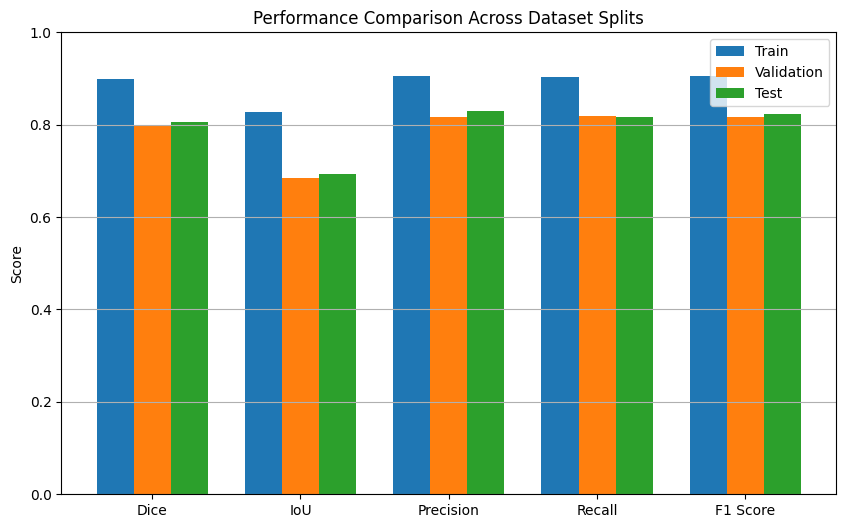

In [ ]:
import numpy as np

metrics = ["Dice","IoU","Precision","Recall","F1 Score"]

train = [
    train_results["Dice"],
    train_results["IoU"],
    train_results["Precision"],
    train_results["Recall"],
    train_results["F1"]
]

val = [
    val_results["Dice"],
    val_results["IoU"],
    val_results["Precision"],
    val_results["Recall"],
    val_results["F1"]
]

test = [
    test_results["Dice"],
    test_results["IoU"],
    test_results["Precision"],
    test_results["Recall"],
    test_results["F1"]
]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(10,6))

plt.bar(x-width, train, width, label="Train")
plt.bar(x, val, width, label="Validation")
plt.bar(x+width, test, width, label="Test")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.ylim(0,1)
plt.title("Performance Comparison Across Dataset Splits")
plt.legend()

plt.grid(axis='y')

plt.show()